In [ ]:

!pip install pandas numpy geopandas h3 osmnx matplotlib seaborn -q

In [ ]:
import pandas as pd
import numpy as np

# A.1. Загружаем xlsx
data = pd.read_excel("кейс_втб.xlsx", sheet_name="data")
target = pd.read_excel("кейс_втб.xlsx", sheet_name="target")

print("data shape:", data.shape)
print("target shape:", target.shape)

data.info()
target.info()

print("Nulls in data:\n", data.isna().sum())
print("Nulls in target:\n", target.isna().sum())

data shape: (99998, 11)
target shape: (51600, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99998 entries, 0 to 99997
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   h3_index        99998 non-null  object 
 1   customer_id     99998 non-null  int64  
 2   datetime_id     99998 non-null  int64  
 3   count           99998 non-null  int64  
 4   sum             99998 non-null  float64
 5   avg             99998 non-null  float64
 6   min             99998 non-null  float64
 7   max             99998 non-null  float64
 8   std             47187 non-null  float64
 9   count_distinct  99998 non-null  int64  
 10  mcc_code        99998 non-null  int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 8.4+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51600 entries, 0 to 51599
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   

In [ ]:
# заполняем std нулями там, где NaN
data["std"] = data["std"].fillna(0.0)

# словарь агрегирования на уровень H3-ячейки
agg_dict = {
    "customer_id": pd.Series.nunique,   # сколько уникальных клиентов в ячейке
    "count": "sum",                     # суммарное количество операций
    "sum": "sum",                       # суммарный оборот
    "avg": "mean",                      # средняя сумма операции
    "min": "min",
    "max": "max",
    "std": "mean",                      # среднее std по строкам
    "count_distinct": "mean"            # среднее count_distinct
}

df_h3 = (
    data
    .groupby("h3_index")
    .agg(agg_dict)
    .reset_index()
    .rename(columns={
        "customer_id": "txn_clients_nunique",
        "count": "txn_count_total",
        "sum": "txn_sum_total",
        "avg": "txn_avg_amount_mean",
        "min": "txn_min_amount",
        "max": "txn_max_amount",
        "std": "txn_std_amount_mean",
        "count_distinct": "txn_count_distinct_mean"
    })
)

df_h3.head()

,h3_index,txn_clients_nunique,txn_count_total,txn_sum_total,txn_avg_amount_mean,txn_min_amount,txn_max_amount,txn_std_amount_mean,txn_count_distinct_mean
0,8911818610bffff,41,104,138804.50,1673.603508,39.0,13188.0,379.142974,1.066667
1,89118195133ffff,8,18,41150.00,3069.318182,50.0,6600.0,8.700971,1.000000
2,8911819513bffff,15,344,87122.85,229.773022,40.0,867.0,87.793331,1.666667
3,891181b2827ffff,19,157,124567.10,606.542377,19.9,4700.0,263.590014,1.846154
4,891181b2957ffff,63,423,213508.00,789.212110,10.0,44396.0,91.113160,1.569444


In [ ]:

time_bucket_map = {
    0: "morning",
    1: "day",
    2: "evening",
    3: "night"
}

data["time_bucket"] = data["datetime_id"].map(time_bucket_map).fillna("other")

# считаем суммарный count по (h3_index, time_bucket)
pivot_time = (
    data
    .groupby(["h3_index", "time_bucket"])["count"]
    .sum()
    .reset_index()
)

# считаем общий count по ячейке
total_by_h3 = (
    pivot_time
    .groupby("h3_index")["count"]
    .sum()
    .rename("count_total_h3")
)

pivot_time = pivot_time.merge(total_by_h3, on="h3_index", how="left")
pivot_time["share"] = pivot_time["count"] / pivot_time["count_total_h3"]

# разворачиваем в wide-формат
pivot_time_wide = (
    pivot_time
    .pivot(index="h3_index", columns="time_bucket", values="share")
    .fillna(0)
)

pivot_time_wide.columns = [f"share_txn_{c}" for c in pivot_time_wide.columns]
pivot_time_wide = pivot_time_wide.reset_index()

# мержим с df_h3
df_h3 = df_h3.merge(pivot_time_wide, on="h3_index", how="left")

df_h3.head()

,h3_index,txn_clients_nunique,txn_count_total,txn_sum_total,txn_avg_amount_mean,txn_min_amount,txn_max_amount,txn_std_amount_mean,txn_count_distinct_mean,share_txn_day,share_txn_evening,share_txn_morning,share_txn_night
0,8911818610bffff,41,104,138804.50,1673.603508,39.0,13188.0,379.142974,1.066667,0.298077,0.298077,0.000000,0.403846
1,89118195133ffff,8,18,41150.00,3069.318182,50.0,6600.0,8.700971,1.000000,0.611111,0.388889,0.000000,0.000000
2,8911819513bffff,15,344,87122.85,229.773022,40.0,867.0,87.793331,1.666667,0.625000,0.325581,0.000000,0.049419
3,891181b2827ffff,19,157,124567.10,606.542377,19.9,4700.0,263.590014,1.846154,0.063694,0.305732,0.000000,0.630573
4,891181b2957ffff,63,423,213508.00,789.212110,10.0,44396.0,91.113160,1.569444,0.224586,0.309693,0.016548,0.449173


In [ ]:
# список h3, где хотя бы один клиент имел банкоматную активность
h3_with_atm_activity = target["h3_index"].drop_duplicates()

df_h3["has_atm_activity"] = df_h3["h3_index"].isin(h3_with_atm_activity).astype(int)

df_h3["has_atm_activity"].value_counts()

,count
has_atm_activity,
1,1567


In [ ]:
print(df_h3.shape)
df_h3.head()

# базовые статистики по ключевым признакам
num_cols = [
    "txn_sum_total", "txn_count_total", "txn_clients_nunique",
    "txn_avg_amount_mean", "txn_std_amount_mean", "txn_count_distinct_mean"
]

df_h3[num_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

(1567, 14)


,txn_sum_total,txn_count_total,txn_clients_nunique,txn_avg_amount_mean,txn_std_amount_mean,txn_count_distinct_mean
count,1.567000e+03,1567.000000,1567.000000,1.567000e+03,1.567000e+03,1567.000000
mean,1.671701e+05,280.085514,32.929164,2.288582e+03,1.133530e+03,1.459077
std,4.589958e+05,1071.309029,59.998005,4.994705e+04,3.492022e+04,0.543854
min,4.500000e+01,1.000000,1.000000,2.900000e+01,0.000000e+00,1.000000
50%,5.120534e+04,74.000000,11.000000,7.225970e+02,1.495032e+02,1.300000
90%,4.459087e+05,627.400000,97.400000,1.907663e+03,4.658483e+02,2.111111
95%,6.810710e+05,962.000000,139.700000,2.685108e+03,7.151143e+02,2.529018
99%,1.199240e+06,2588.360000,254.340000,6.583318e+03,1.960625e+03,3.606897
max,1.056741e+07,27269.000000,896.000000,1.977500e+06,1.382394e+06,5.769231


In [ ]:
!pip install h3 osmnx geopandas shapely -q

In [ ]:
import h3
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import numpy as np

In [ ]:
print("H3 version:", h3.__version__)

def h3_to_latlon(h):
    """(lat, lon) центра ячейки H3, версия-независимо."""
    if hasattr(h3, "cell_to_latlng"):
        lat, lon = h3.cell_to_latlng(h)
    else:
        lat, lon = h3.h3_to_geo(h)
    return lat, lon

def latlon_to_h3(lat, lon, res):
    """Обратное преобразование lat/lon -> H3."""
    if hasattr(h3, "latlng_to_cell"):
        return h3.latlng_to_cell(lat, lon, res)
    else:
        return h3.geo_to_h3(lat, lon, res)

H3 version: 4.4.2


In [ ]:
df_h3["lat"], df_h3["lon"] = zip(*df_h3["h3_index"].map(h3_to_latlon))

df_h3[["h3_index", "lat", "lon"]].head()

,h3_index,lat,lon
0,8911818610bffff,55.351430,37.336013
1,89118195133ffff,55.291298,37.183182
2,8911819513bffff,55.288432,37.185203
3,891181b2827ffff,55.503972,37.557006
4,891181b2957ffff,55.509123,37.563214


In [ ]:
# центр всех ячеек
center_lat = df_h3["lat"].mean()
center_lon = df_h3["lon"].mean()
center_point = (center_lat, center_lon)

# радиус в метрах (20 км как старт)
dist_m = 2000

# теги интересных объектов
tags = {
    "amenity": [
        "bank", "atm", "hospital", "clinic", "school", "university",
        "bus_station", "cafe", "restaurant", "bar", "fast_food"
    ],
    "shop": [
        "mall", "supermarket", "convenience", "department_store"
    ],
    "building": [
        "retail", "commercial", "office"
    ],
    "public_transport": True,
    "railway": ["station", "subway_entrance"]
}

pois = ox.features_from_point(center_point, tags, dist=dist_m)
pois = pois.reset_index()
pois.head()

,element,id,geometry,colour,description,network,operator,railway,ref,wheelchair,...,service:vehicle:car_repair,service:vehicle:car_wash,service:vehicle:ceramic_coating,service:vehicle:detailing,service:vehicle:interior_cleaning,service:vehicle:painting,service:vehicle:polishing,service:vehicle:protective_film,service:vehicle:scratch_removal,service:vehicle:window_tinting
0,node,60295631,POINT (37.61263 55.7313),orange,Калужско-Рижская линия,Московский метрополитен,ГУП «Московский метрополитен»,subway_entrance,3,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,60767667,POINT (37.6114 55.72925),brown,Кольцевая линия,Московский метрополитен,ГУП «Московский метрополитен»,subway_entrance,1,yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,60901994,POINT (37.58066 55.72744),red,NaN,Московский метрополитен,ГУП «Московский метрополитен»,subway_entrance,1,yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,238151947,POINT (37.5838 55.74792),blue,Арбатско-Покровская линия,Московский метрополитен,ГУП «Московский метрополитен»,subway_entrance,NaN,no,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,238154965,POINT (37.58217 55.74894),lightblue,Филёвская линия,Московский метрополитен,ГУП «Московский метрополитен»,subway_entrance,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# геометрия -> центроид (на случай полигонов)
pois["geometry"] = pois["geometry"].centroid

def categorize_poi(row):
    amenity = row.get("amenity", None)
    shop = row.get("shop", None)
    building = row.get("building", None)
    railway = row.get("railway", None)
    public_transport = row.get("public_transport", None)

    if amenity in ["bank", "atm"]:
        return "finance"
    if shop in ["mall", "department_store"]:
        return "mall"
    if shop in ["supermarket", "convenience"]:
        return "grocery"
    if amenity in ["cafe", "restaurant", "bar", "fast_food"]:
        return "food"
    if amenity in ["school", "university"]:
        return "education"
    if amenity in ["hospital", "clinic"]:
        return "health"
    if railway in ["station", "subway_entrance"] or public_transport:
        return "transport"
    if building in ["office", "commercial", "retail"]:
        return "office"
    return "other"

pois["poi_type"] = pois.apply(categorize_poi, axis=1)

pois[["geometry", "amenity", "shop", "building", "railway", "public_transport", "poi_type"]].head()

/tmp/ipykernel_506/4201421521.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pois["geometry"] = pois["geometry"].centroid


,geometry,amenity,shop,building,railway,public_transport,poi_type
0,POINT (37.61263 55.7313),NaN,NaN,NaN,subway_entrance,NaN,transport
1,POINT (37.6114 55.72925),NaN,NaN,NaN,subway_entrance,NaN,transport
2,POINT (37.58066 55.72744),NaN,NaN,NaN,subway_entrance,NaN,transport
3,POINT (37.5838 55.74792),NaN,NaN,NaN,subway_entrance,NaN,transport
4,POINT (37.58217 55.74894),NaN,NaN,NaN,subway_entrance,NaN,transport


In [ ]:
# определяем resolution H3
if hasattr(h3, "get_resolution"):
    H3_RES = h3.get_resolution(df_h3["h3_index"].iloc[0])
else:
    H3_RES = 9  # запасной вариант

print("H3 resolution:", H3_RES)

def point_to_h3(point, res):
    lat, lon = point.y, point.x
    return latlon_to_h3(lat, lon, res)

pois["h3_index"] = pois["geometry"].apply(lambda p: point_to_h3(p, H3_RES))

# оставляем только те ячейки, которые есть в df_h3
pois = pois[pois["h3_index"].isin(df_h3["h3_index"])]

# считаем количество POI каждого типа по ячейке
poi_counts = (
    pois
    .groupby(["h3_index", "poi_type"])
    .size()
    .reset_index(name="poi_count")
)

poi_pivot = (
    poi_counts
    .pivot(index="h3_index", columns="poi_type", values="poi_count")
    .fillna(0)
)

poi_pivot.columns = [f"poi_{c}_cnt" for c in poi_pivot.columns]
poi_pivot = poi_pivot.reset_index()

poi_pivot.head()

H3 resolution: 9


,h3_index,poi_education_cnt,poi_finance_cnt,poi_food_cnt,poi_grocery_cnt,poi_health_cnt,poi_mall_cnt,poi_transport_cnt
0,8911aa78113ffff,0.0,0.0,1.0,0.0,0.0,0.0,7.0
1,8911aa78183ffff,1.0,1.0,10.0,1.0,0.0,1.0,13.0
2,8911aa78187ffff,0.0,1.0,3.0,0.0,0.0,0.0,10.0
3,8911aa7818fffff,0.0,1.0,1.0,0.0,2.0,0.0,2.0
4,8911aa78197ffff,0.0,4.0,12.0,2.0,1.0,0.0,17.0


In [ ]:
# мержим с df_h3
df_h3 = df_h3.merge(poi_pivot, on="h3_index", how="left")

poi_cols = [c for c in df_h3.columns if c.startswith("poi_")]
df_h3[poi_cols] = df_h3[poi_cols].fillna(0)

df_h3[["h3_index"] + poi_cols].head()

,h3_index,poi_education_cnt,poi_finance_cnt,poi_food_cnt,poi_grocery_cnt,poi_health_cnt,poi_mall_cnt,poi_transport_cnt
0,8911818610bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,89118195133ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,8911819513bffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,891181b2827ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,891181b2957ffff,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Транзакционный потенциал
df_h3["txn_potential"] = (
    0.5 * df_h3["txn_sum_total"].clip(lower=0) +
    0.3 * df_h3["txn_count_total"].clip(lower=0) +
    0.2 * df_h3["txn_clients_nunique"].clip(lower=0)
)

# 2. Инфраструктурный потенциал (сумма всех POI по типам)
poi_cols = [c for c in df_h3.columns if c.startswith("poi_")]
df_h3["poi_potential"] = df_h3[poi_cols].sum(axis=1)

# 3. Нормализация
scaler = MinMaxScaler()
df_h3[["txn_potential_norm", "poi_potential_norm"]] = scaler.fit_transform(
    df_h3[["txn_potential", "poi_potential"]]
)

# 4. Итоговый скор зоны
W_TXN = 0.7  # транзакции важнее
W_POI = 0.3  # инфраструктура как усилитель

df_h3["zone_score"] = (
    W_TXN * df_h3["txn_potential_norm"] +
    W_POI * df_h3["poi_potential_norm"]
)

df_h3[["h3_index", "txn_potential", "poi_potential", "zone_score"]].head()

,h3_index,txn_potential,poi_potential,zone_score
0,8911818610bffff,69441.650,0.0,0.009184
1,89118195133ffff,20582.000,0.0,0.002720
2,8911819513bffff,43667.625,0.0,0.005774
3,891181b2827ffff,62334.450,0.0,0.008243
4,891181b2957ffff,106893.500,0.0,0.014138


In [ ]:
# кандидаты: высокие zone_score, но нет текущей ATM-активности
candidates = (
    df_h3[df_h3["has_atm_activity"] == 0]
    .sort_values("zone_score", ascending=False)
    .head(20)
)

cols_for_view = [
    "h3_index", "zone_score",
    "txn_sum_total", "txn_count_total", "txn_clients_nunique"
] + poi_cols

candidates[cols_for_view]

,h3_index,zone_score,txn_sum_total,txn_count_total,txn_clients_nunique,poi_education_cnt,poi_finance_cnt,poi_food_cnt,poi_grocery_cnt,poi_health_cnt,poi_mall_cnt,poi_transport_cnt


In [ ]:
client_cols = [
    "txn_sum_total",
    "txn_count_total",
    "txn_clients_nunique",
    "txn_avg_amount_mean",
    "txn_std_amount_mean",
    "txn_count_distinct_mean"
]

summary_clients = (
    df_h3
    .groupby("has_atm_activity")[client_cols]
    .agg(["mean", "median"])
    .T
)

summary_clients

has_atm_activity                            1
txn_sum_total           mean    167170.078404
                        median   51205.340000
txn_count_total         mean       280.085514
                        median      74.000000
txn_clients_nunique     mean        32.929164
                        median      11.000000
txn_avg_amount_mean     mean      2288.582463
                        median     722.597029
txn_std_amount_mean     mean      1133.530101
                        median     149.503220
txn_count_distinct_mean mean         1.459077
                        median       1.300000

In [ ]:
infra_cols = poi_cols  # все poi_

summary_infra = (
    df_h3
    .groupby("has_atm_activity")[infra_cols]
    .agg(["mean", "median"])
    .T
)

summary_infra

has_atm_activity                 1
poi_education_cnt mean    0.021698
                  median  0.000000
poi_finance_cnt   mean    0.083599
                  median  0.000000
poi_food_cnt      mean    0.398851
                  median  0.000000
poi_grocery_cnt   mean    0.052329
                  median  0.000000
poi_health_cnt    mean    0.043395
                  median  0.000000
poi_mall_cnt      mean    0.007658
                  median  0.000000
poi_transport_cnt mean    0.554563
                  median  0.000000

In [ ]:
time_cols = [c for c in df_h3.columns if c.startswith("share_txn_")]

summary_time = (
    df_h3
    .groupby("has_atm_activity")[time_cols]
    .agg(["mean"])
    .T
)

summary_time

,has_atm_activity,1
share_txn_day,mean,0.246077
share_txn_evening,mean,0.395778
share_txn_morning,mean,0.013176
share_txn_night,mean,0.344970


In [ ]:
# Правильный таргет: h3_index имеет хотя бы одного клиента,
# который присутствует и в data, и в target

# Уникальные h3+customer из target (кто уже пользовался ATM)
atm_pairs = target[["h3_index", "customer_id"]].drop_duplicates()

# Уникальные h3+customer из data
data_pairs = data[["h3_index", "customer_id"]].drop_duplicates()

# Пересечение: клиенты, которые есть в data И в target для той же h3
matched = data_pairs.merge(atm_pairs, on=["h3_index", "customer_id"], how="inner")

print("matched shape:", matched.shape)
print("unique h3 in matched:", matched["h3_index"].nunique())

# Флаг на уровне h3_index
h3_with_atm = set(matched["h3_index"].unique())
df_h3["has_atm_activity"] = df_h3["h3_index"].isin(h3_with_atm).astype(int)

print(df_h3["has_atm_activity"].value_counts())

matched shape: (51600, 2)
unique h3 in matched: 1567
has_atm_activity
1    1567
Name: count, dtype: int64


Графики

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# стиль
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

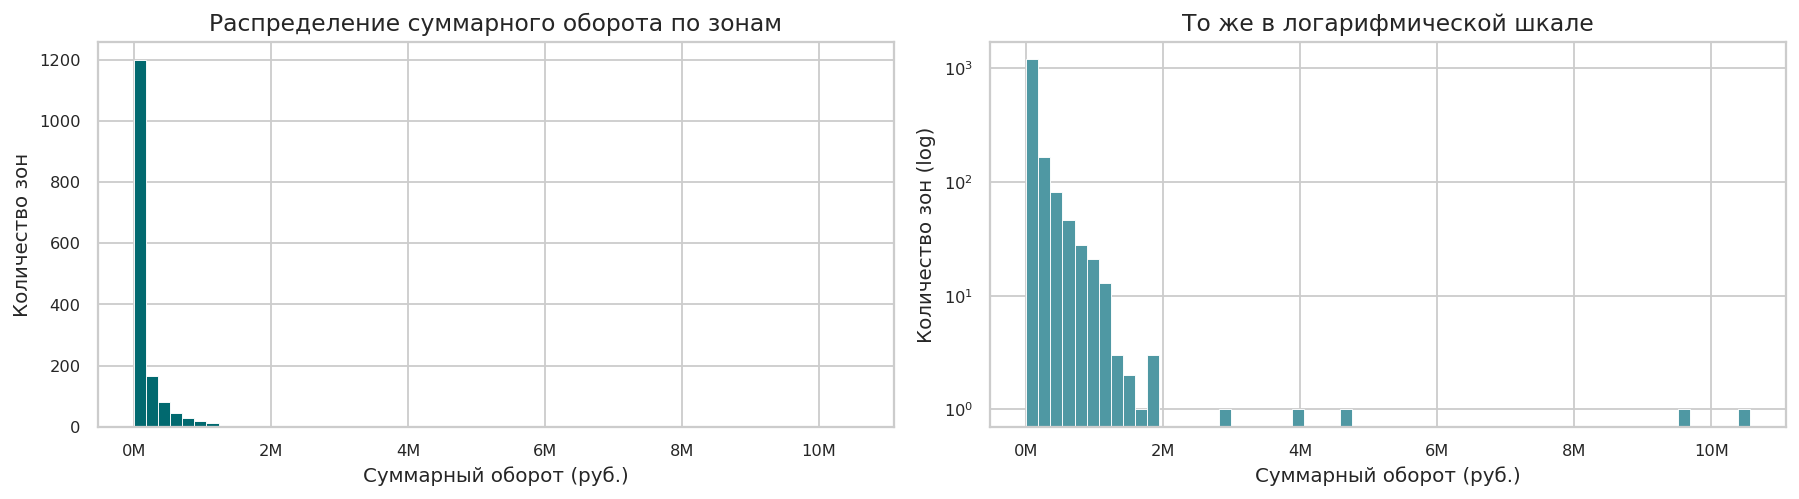

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# гистограмма
axes[0].hist(df_h3["txn_sum_total"], bins=60, color="#01696f", edgecolor="white", linewidth=0.5)
axes[0].set_title("Распределение суммарного оборота по зонам")
axes[0].set_xlabel("Суммарный оборот (руб.)")
axes[0].set_ylabel("Количество зон")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

# log-шкала
axes[1].hist(df_h3["txn_sum_total"], bins=60, color="#4f98a3", edgecolor="white", linewidth=0.5)
axes[1].set_yscale("log")
axes[1].set_title("То же в логарифмической шкале")
axes[1].set_xlabel("Суммарный оборот (руб.)")
axes[1].set_ylabel("Количество зон (log)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

plt.tight_layout()
plt.savefig("plot_01_oborot_distribution.png", bbox_inches="tight")
plt.show()

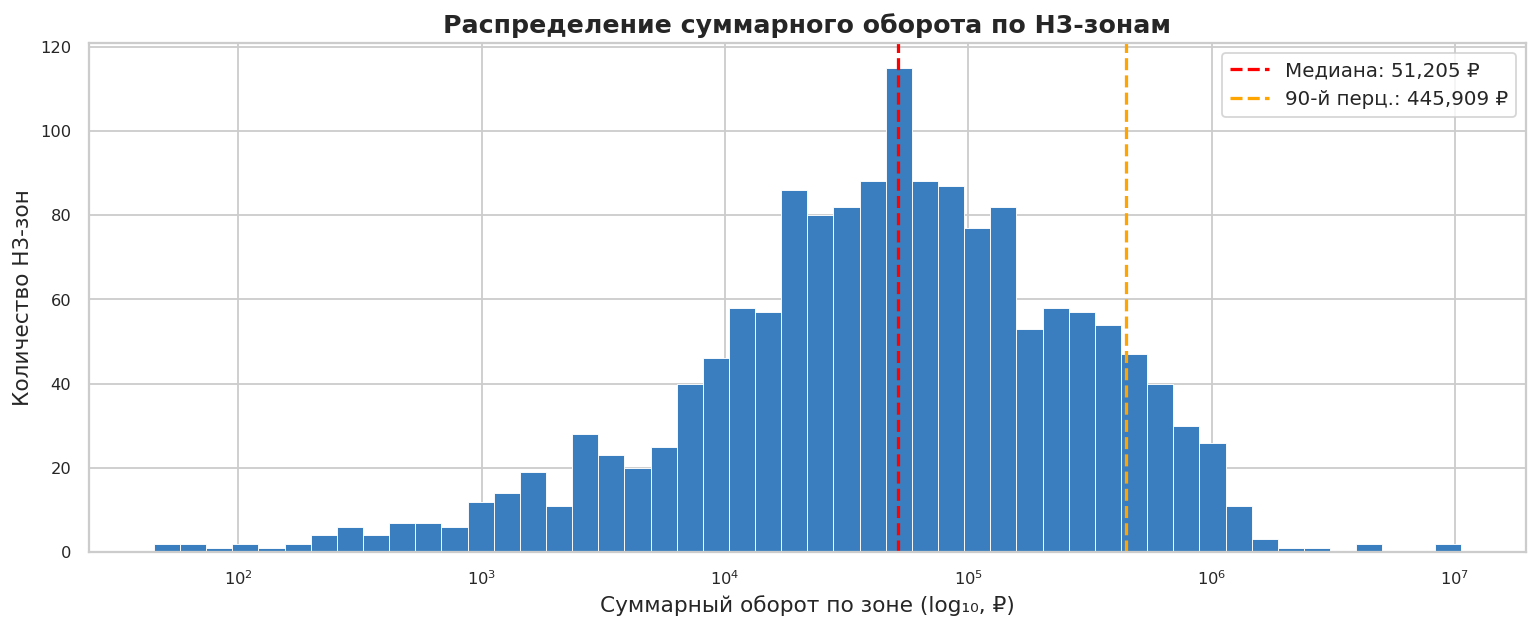

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(12, 5))

# логарифм оборота (убираем нули)
log_values = np.log10(df_h3["txn_sum_total"].replace(0, np.nan).dropna())

ax.hist(log_values, bins=50, color="#3a7ebf", edgecolor="white", linewidth=0.5)

# медиана и P90 в log-шкале
median_val = df_h3["txn_sum_total"].median()
p90_val = df_h3["txn_sum_total"].quantile(0.9)

ax.axvline(np.log10(median_val), linestyle="--", color="red", linewidth=1.8,
           label=f"Медиана: {median_val:,.0f} ₽")
ax.axvline(np.log10(p90_val), linestyle="--", color="orange", linewidth=1.8,
           label=f"90-й перц.: {p90_val:,.0f} ₽")

# подписи оси X: показываем реальные значения (10^3, 10^4 ...)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"$10^{{{int(x)}}}$")
)

ax.set_title("Распределение суммарного оборота по Н3-зонам", fontsize=14, fontweight="bold")
ax.set_xlabel("Суммарный оборот по зоне (log₁₀, ₽)", fontsize=12)
ax.set_ylabel("Количество Н3-зон", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("plot_oborot_log.png", bbox_inches="tight", dpi=150)
plt.show()

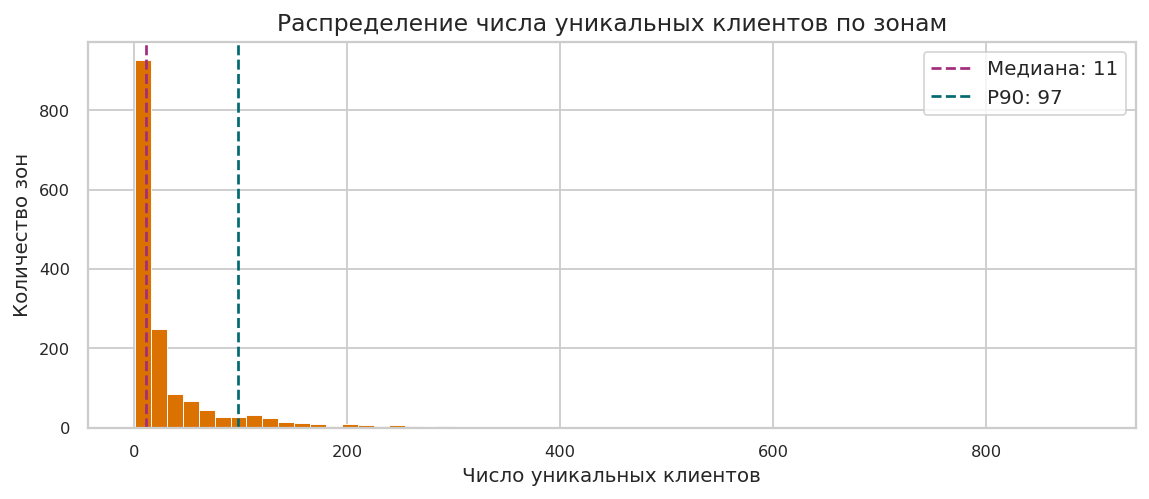

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df_h3["txn_clients_nunique"], bins=60, color="#da7101", edgecolor="white", linewidth=0.5)
ax.set_title("Распределение числа уникальных клиентов по зонам")
ax.set_xlabel("Число уникальных клиентов")
ax.set_ylabel("Количество зон")

# медиана и p90
for pct, label, color in [
    (df_h3["txn_clients_nunique"].median(), "Медиана", "#a12c7b"),
    (df_h3["txn_clients_nunique"].quantile(0.9), "P90", "#01696f"),
]:
    ax.axvline(pct, linestyle="--", color=color, linewidth=1.5, label=f"{label}: {pct:.0f}")

ax.legend()
plt.tight_layout()
plt.savefig("plot_02_clients_distribution.png", bbox_inches="tight")
plt.show()

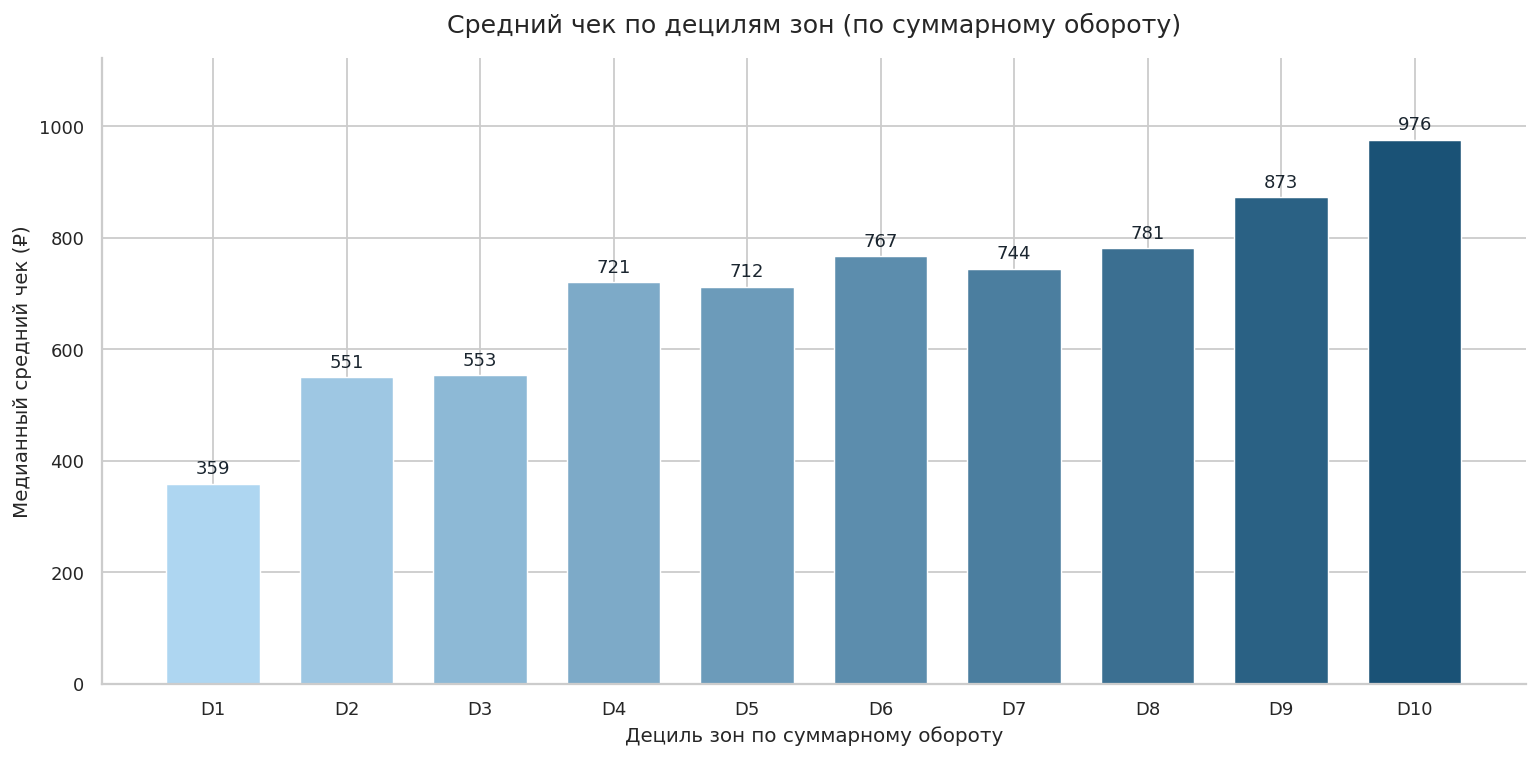

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 1. Считаем дециль каждой зоны по суммарному обороту
df_h3["decile"] = pd.qcut(
    df_h3["txn_sum_total"],
    q=10,
    labels=[f"D{i}" for i in range(1, 11)]
)

# 2. Медианный средний чек по каждому децилю
decile_check = (
    df_h3
    .groupby("decile", observed=True)["txn_avg_amount_mean"]
    .median()
    .reset_index()
)
decile_check.columns = ["decile", "median_avg_check"]

# 3. Цветовой градиент: светло-голубой → тёмно-синий
n = len(decile_check)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_gradient", ["#aed6f1", "#1a5276"], N=n
)
colors = [cmap(i / (n - 1)) for i in range(n)]

# 4. Строим график
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    decile_check["decile"].astype(str),
    decile_check["median_avg_check"],
    color=colors,
    width=0.7,
    edgecolor="white",
    linewidth=0.8
)

# 5. Подписи над столбцами
for bar, val in zip(bars, decile_check["median_avg_check"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{val:.0f}",
        ha="center", va="bottom",
        fontsize=10, color="#1a252f"
    )

# 6. Оформление
ax.set_title("Средний чек по децилям зон (по суммарному обороту)", fontsize=14, pad=14)
ax.set_xlabel("Дециль зон по суммарному обороту", fontsize=11)
ax.set_ylabel("Медианный средний чек (₽)", fontsize=11)
ax.set_ylim(0, decile_check["median_avg_check"].max() * 1.15)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("plot3_avg_check_decile.png", dpi=150, bbox_inches="tight")
plt.show()

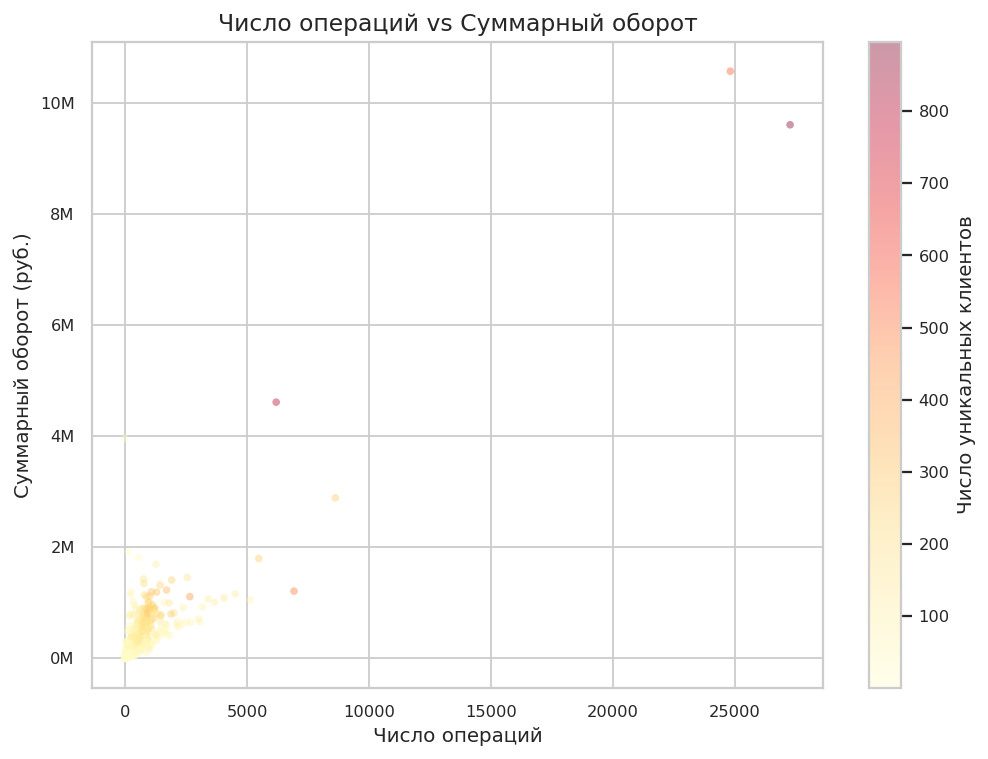

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    df_h3["txn_count_total"],
    df_h3["txn_sum_total"],
    alpha=0.4,
    s=18,
    c=df_h3["txn_clients_nunique"],
    cmap="YlOrRd",
    edgecolors="none"
)

plt.colorbar(sc, ax=ax, label="Число уникальных клиентов")
ax.set_title("Число операций vs Суммарный оборот")
ax.set_xlabel("Число операций")
ax.set_ylabel("Суммарный оборот (руб.)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))

plt.tight_layout()
plt.savefig("plot_03_scatter_count_vs_sum.png", bbox_inches="tight")
plt.show()

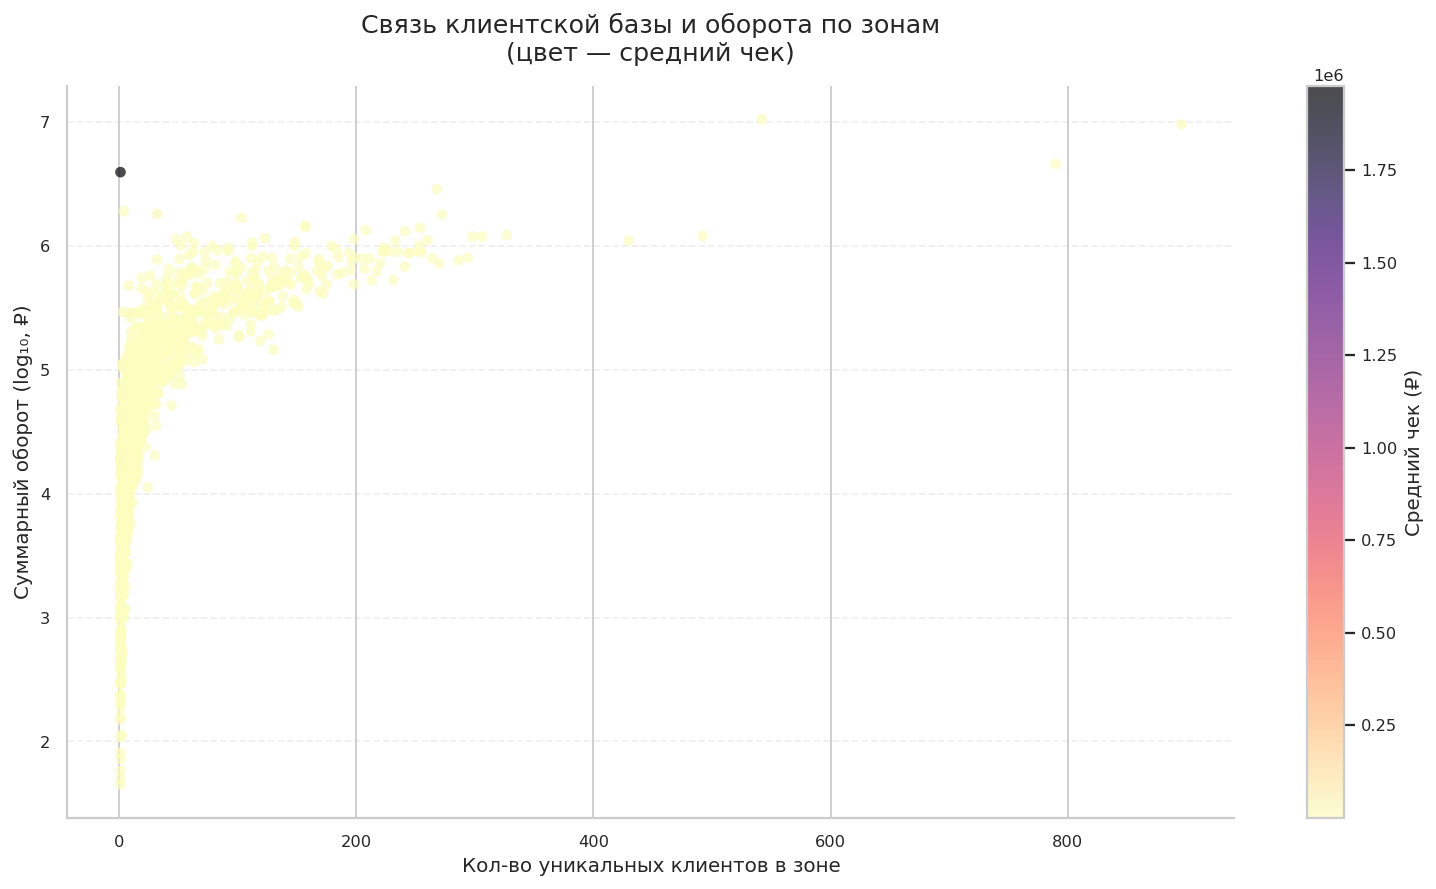

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Берём только нужные колонки и убираем NaN
df_plot = df_h3[["txn_clients_nunique", "txn_sum_total", "txn_avg_amount_mean"]].dropna()

# Логарифм по основанию 10 от суммарного оборота
df_plot["log_turnover"] = np.log10(df_plot["txn_sum_total"].clip(lower=1))

fig, ax = plt.subplots(figsize=(12, 7))

sc = ax.scatter(
    df_plot["txn_clients_nunique"],
    df_plot["log_turnover"],
    c=df_plot["txn_avg_amount_mean"],
    cmap="magma_r",        # жёлто‑оранжево‑розовый градиент
    alpha=0.7,
    s=35,
    edgecolors="none"
)

# Цветовая шкала
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Средний чек (₽)", fontsize=11)

# Оформление
ax.set_title(
    "Связь клиентской базы и оборота по зонам\n(цвет — средний чек)",
    fontsize=14,
    pad=14
)
ax.set_xlabel("Кол-во уникальных клиентов в зоне", fontsize=11)
ax.set_ylabel("Суммарный оборот (log₁₀, ₽)", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("plot7_clients_vs_turnover.png", dpi=150, bbox_inches="tight")
plt.show()

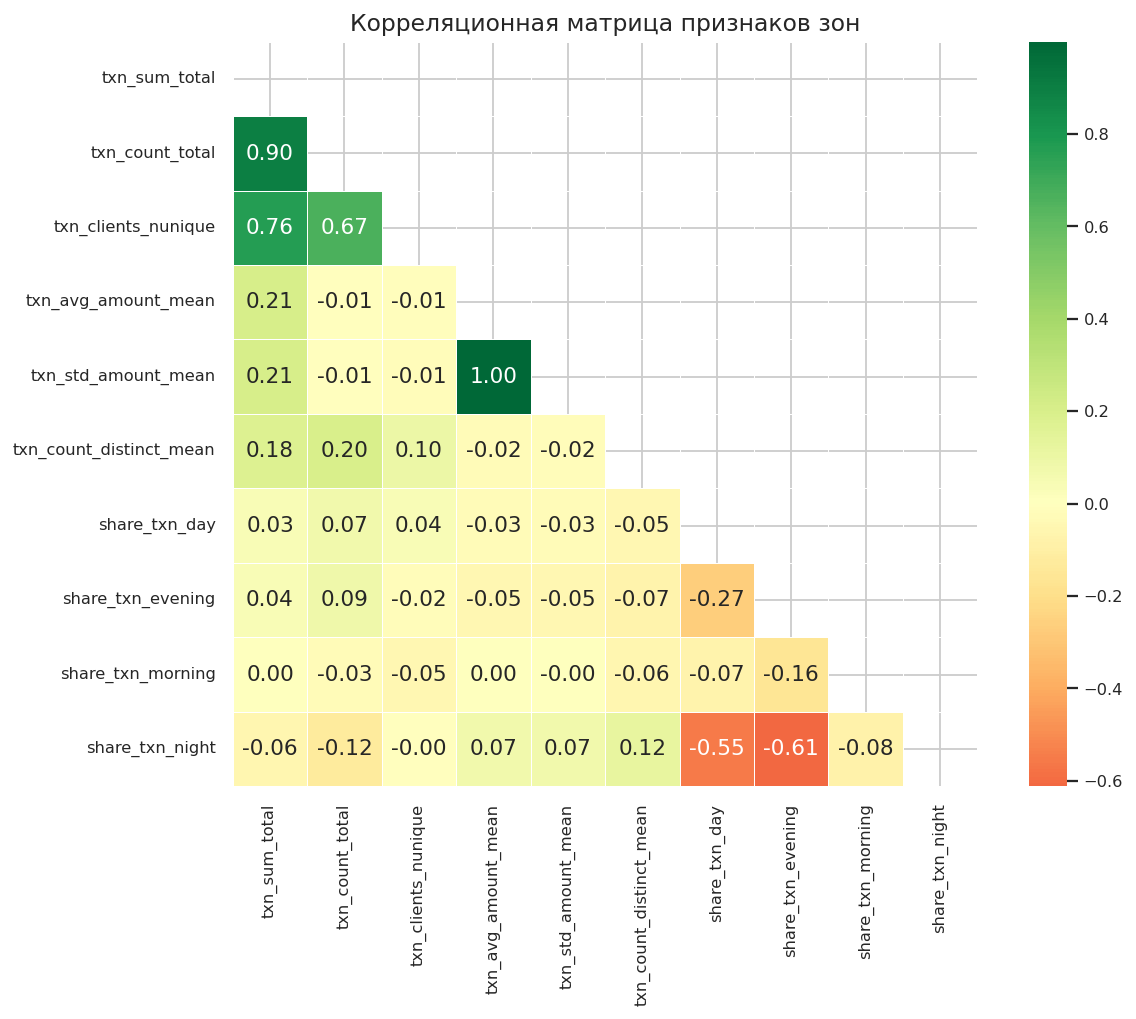

In [ ]:
corr_cols = [
    "txn_sum_total",
    "txn_count_total",
    "txn_clients_nunique",
    "txn_avg_amount_mean",
    "txn_std_amount_mean",
    "txn_count_distinct_mean",
]
# добавляем временные, если есть
time_cols = [c for c in df_h3.columns if c.startswith("share_txn_")]
corr_cols += time_cols
corr_cols = [c for c in corr_cols if c in df_h3.columns]

corr_matrix = df_h3[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Корреляционная матрица признаков зон")
plt.tight_layout()
plt.savefig("plot_04_correlation_matrix.png", bbox_inches="tight")
plt.show()

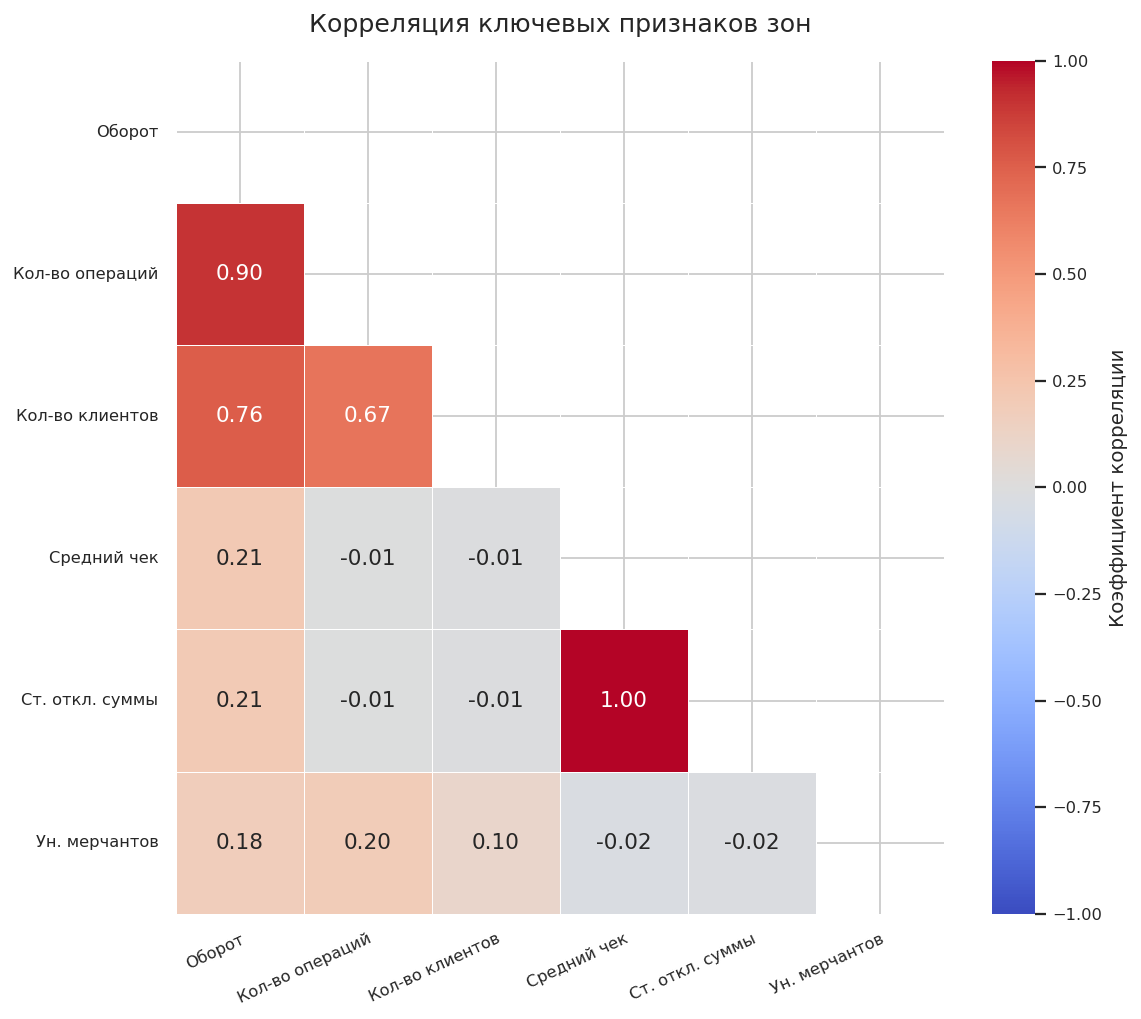

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Выбираем нужные признаки
corr_cols = [
    "txn_sum_total",
    "txn_count_total",
    "txn_clients_nunique",
    "txn_avg_amount_mean",
    "txn_std_amount_mean",
    "txn_count_distinct_mean",
]

corr_cols = [c for c in corr_cols if c in df_h3.columns]

# матрица корреляций
corr_matrix = df_h3[corr_cols].corr()

# 2. Русские подписи осей
display_names = {
    "txn_sum_total": "Оборот",
    "txn_count_total": "Кол-во операций",
    "txn_clients_nunique": "Кол-во клиентов",
    "txn_avg_amount_mean": "Средний чек",
    "txn_std_amount_mean": "Ст. откл. суммы",
    "txn_count_distinct_mean": "Ун. мерчантов",
}

corr_matrix_display = corr_matrix.copy()
corr_matrix_display.index = [display_names.get(c, c) for c in corr_matrix.index]
corr_matrix_display.columns = [display_names.get(c, c) for c in corr_matrix.columns]

# 3. Маска для верхнего треугольника
mask = np.triu(np.ones_like(corr_matrix_display, dtype=bool))

# 4. Построение теплокарты
fig, ax = plt.subplots(figsize=(9, 8))

sns.heatmap(
    corr_matrix_display,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Коэффициент корреляции"},
    ax=ax
)

ax.set_title("Корреляция ключевых признаков зон", fontsize=14, pad=16)

# поворачиваем подписи осей
plt.setp(ax.get_xticklabels(), rotation=25, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("plot6_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

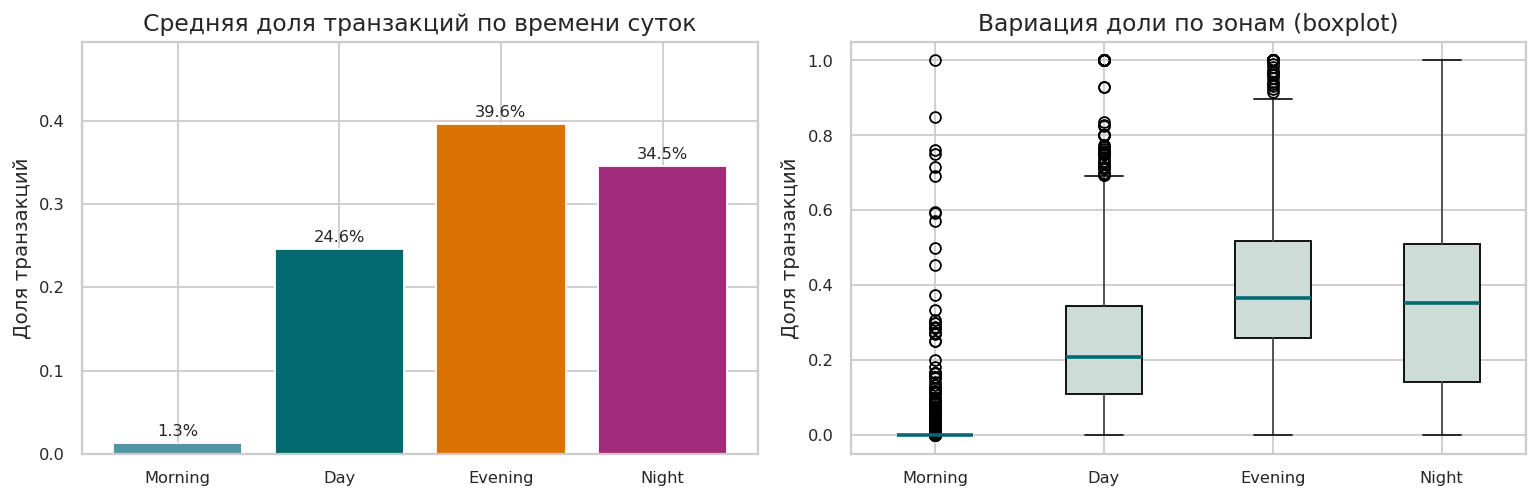

In [ ]:
time_cols_present = [c for c in ["share_txn_morning","share_txn_day","share_txn_evening","share_txn_night"]
                     if c in df_h3.columns]

if time_cols_present:
    time_means = df_h3[time_cols_present].mean()
    labels = [c.replace("share_txn_", "").capitalize() for c in time_cols_present]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # столбчатая
    bars = axes[0].bar(labels, time_means.values, color=["#4f98a3","#01696f","#da7101","#a12c7b"],
                       edgecolor="white")
    axes[0].set_title("Средняя доля транзакций по времени суток")
    axes[0].set_ylabel("Доля транзакций")
    axes[0].set_ylim(0, time_means.max() * 1.25)
    for bar, val in zip(bars, time_means.values):
        axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                     f"{val:.1%}", ha="center", va="bottom", fontsize=9)

    # boxplot
    df_h3[time_cols_present].rename(
        columns={c: c.replace("share_txn_","").capitalize() for c in time_cols_present}
    ).boxplot(ax=axes[1], patch_artist=True,
              boxprops=dict(facecolor="#cedcd8"), medianprops=dict(color="#01696f", linewidth=2))
    axes[1].set_title("Вариация доли по зонам (boxplot)")
    axes[1].set_ylabel("Доля транзакций")

    plt.tight_layout()
    plt.savefig("plot_05_time_profile.png", bbox_inches="tight")
    plt.show()

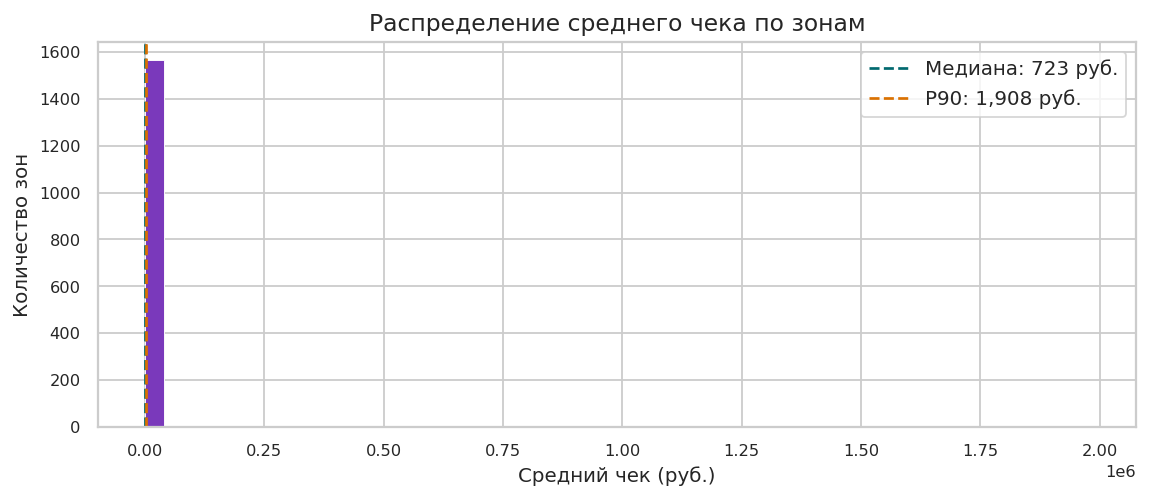

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(df_h3["txn_avg_amount_mean"].dropna(), bins=50,
        color="#7a39bb", edgecolor="white", linewidth=0.5)
ax.set_title("Распределение среднего чека по зонам")
ax.set_xlabel("Средний чек (руб.)")
ax.set_ylabel("Количество зон")

for pct, label, color in [
    (df_h3["txn_avg_amount_mean"].median(), "Медиана", "#01696f"),
    (df_h3["txn_avg_amount_mean"].quantile(0.9), "P90", "#da7101"),
]:
    ax.axvline(pct, linestyle="--", color=color, linewidth=1.5, label=f"{label}: {pct:,.0f} руб.")

ax.legend()
plt.tight_layout()
plt.savefig("plot_07_avg_amount.png", bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Признаки, которые пойдут в скор
txn_cols = [
    "txn_sum_total",
    "txn_count_total",
    "txn_clients_nunique",
    "txn_avg_amount_mean",
    "txn_std_amount_mean"
]

time_cols = [c for c in df_h3.columns if c.startswith("share_txn_")]
poi_cols  = [c for c in df_h3.columns if c.startswith("poi_")]

feature_cols = txn_cols + time_cols + poi_cols

# 2. Нормализация 0–1
scaler = MinMaxScaler()
df_h3_scaled = df_h3.copy()
df_h3_scaled[feature_cols] = scaler.fit_transform(df_h3[feature_cols])

# 3. Компоненты скора
df_h3_scaled["score_txn"] = (
    0.5 * df_h3_scaled["txn_sum_total"] +
    0.3 * df_h3_scaled["txn_count_total"] +
    0.2 * df_h3_scaled["txn_clients_nunique"]
)

df_h3_scaled["score_behavior"] = (
    df_h3_scaled.get("share_txn_day", 0) +
    df_h3_scaled.get("share_txn_evening", 0)
) / 2  # зоны с сильным дневным+вечерним спросом

df_h3_scaled["score_infra"] = df_h3_scaled[poi_cols].mean(axis=1)  # средняя насыщенность POI

# 4. Итоговый интегральный скор
W_TXN = 0.6
W_BEH = 0.2
W_INF = 0.2

df_h3_scaled["zone_score"] = (
    W_TXN * df_h3_scaled["score_txn"] +
    W_BEH * df_h3_scaled["score_behavior"] +
    W_INF * df_h3_scaled["score_infra"]
)

df_h3_scaled[["h3_index", "score_txn", "score_behavior", "score_infra", "zone_score"]].head()

,h3_index,score_txn,score_behavior,score_infra,zone_score
0,8911818610bffff,0.016637,0.298077,0.0,0.069598
1,89118195133ffff,0.003696,0.500000,0.0,0.102218
2,8911819513bffff,0.011022,0.475291,0.0,0.101672
3,891181b2827ffff,0.011630,0.184713,0.0,0.043921
4,891181b2957ffff,0.028598,0.267139,0.0,0.070586


In [ ]:
top_zones = (
    df_h3_scaled
    .sort_values("zone_score", ascending=False)
    .head(20)
)

cols_for_view = [
    "h3_index",
    "zone_score",
    "score_txn",
    "score_behavior",
    "score_infra",
    "txn_sum_total",
    "txn_clients_nunique"
] + poi_cols

top_zones[cols_for_view]

,h3_index,zone_score,score_txn,score_behavior,score_infra,txn_sum_total,txn_clients_nunique,poi_education_cnt,poi_finance_cnt,poi_food_cnt,poi_grocery_cnt,poi_health_cnt,poi_mall_cnt,poi_transport_cnt,poi_potential,poi_potential_norm
1276,8911aa7a117ffff,0.670282,0.954405,0.488192,0.000000,0.908811,1.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
556,8911aa6365bffff,0.635735,0.893939,0.496857,0.000000,1.000000,0.604469,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1437,8911aa7abd3ffff,0.418146,0.462626,0.322765,0.380088,0.436269,0.881564,0.0,0.4,0.736842,0.142857,0.0,1.0,0.239130,0.450980,0.450980
1488,8911aa7aec7ffff,0.294093,0.149669,0.299236,0.722222,0.116233,0.364246,0.0,1.0,1.000000,1.000000,0.0,0.5,1.000000,1.000000,1.000000
565,8911aa636c7ffff,0.273779,0.291159,0.495418,0.000000,0.273315,0.298324,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
554,8911aa63653ffff,0.219653,0.205862,0.480678,0.000000,0.169916,0.302793,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1482,8911aa7ae3bffff,0.218635,0.051115,0.355046,0.584784,0.041545,0.121788,0.0,0.7,0.684211,0.571429,0.2,1.0,0.695652,0.705882,0.705882
1367,8911aa7a967ffff,0.210333,0.243133,0.322269,0.000000,0.114382,0.548603,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
1489,8911aa7aed7ffff,0.206611,0.131780,0.474736,0.162980,0.137685,0.174302,0.0,0.4,0.157895,0.142857,0.2,0.0,0.173913,0.196078,0.196078
1487,8911aa7aeafffff,0.189695,0.112659,0.493243,0.117253,0.100830,0.124022,0.0,0.3,0.052632,0.000000,0.4,0.0,0.086957,0.107843,0.107843


In [ ]:
from sklearn.cluster import KMeans

X = df_h3_scaled[feature_cols]

kmeans = KMeans(n_clusters=5, random_state=42)
df_h3_scaled["cluster"] = kmeans.fit_predict(X)

# средний скор по кластерам
cluster_stats = (
    df_h3_scaled
    .groupby("cluster")["zone_score"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

cluster_stats

,mean,count
cluster,,
4,0.118732,247
1,0.093503,215
0,0.089251,180
3,0.071324,608
2,0.036883,317


In [ ]:
best_cluster = cluster_stats.index[0]

lookalike_zones = (
    df_h3_scaled[df_h3_scaled["cluster"] == best_cluster]
    .sort_values("zone_score", ascending=False)
    .head(20)
)

lookalike_zones[cols_for_view + ["cluster"]]

,h3_index,zone_score,score_txn,score_behavior,score_infra,txn_sum_total,txn_clients_nunique,poi_education_cnt,poi_finance_cnt,poi_food_cnt,poi_grocery_cnt,poi_health_cnt,poi_mall_cnt,poi_transport_cnt,poi_potential,poi_potential_norm,cluster
1276,8911aa7a117ffff,0.670282,0.954405,0.488192,0.000000,0.908811,1.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,4
556,8911aa6365bffff,0.635735,0.893939,0.496857,0.000000,1.000000,0.604469,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,4
1437,8911aa7abd3ffff,0.418146,0.462626,0.322765,0.380088,0.436269,0.881564,0.0,0.4,0.736842,0.142857,0.0,1.0,0.239130,0.450980,0.450980,4
1488,8911aa7aec7ffff,0.294093,0.149669,0.299236,0.722222,0.116233,0.364246,0.0,1.0,1.000000,1.000000,0.0,0.5,1.000000,1.000000,1.000000,4
565,8911aa636c7ffff,0.273779,0.291159,0.495418,0.000000,0.273315,0.298324,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,4
554,8911aa63653ffff,0.219653,0.205862,0.480678,0.000000,0.169916,0.302793,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,4
1482,8911aa7ae3bffff,0.218635,0.051115,0.355046,0.584784,0.041545,0.121788,0.0,0.7,0.684211,0.571429,0.2,1.0,0.695652,0.705882,0.705882,4
1489,8911aa7aed7ffff,0.206611,0.131780,0.474736,0.162980,0.137685,0.174302,0.0,0.4,0.157895,0.142857,0.2,0.0,0.173913,0.196078,0.196078,4
1487,8911aa7aeafffff,0.189695,0.112659,0.493243,0.117253,0.100830,0.124022,0.0,0.3,0.052632,0.000000,0.4,0.0,0.086957,0.107843,0.107843,4
1400,8911aa7aad7ffff,0.189327,0.049361,0.498912,0.299642,0.038614,0.049162,0.0,0.2,0.210526,0.142857,0.4,0.0,0.782609,0.480392,0.480392,4


In [ ]:
# 1. Кластеризация H3-зон по транзакциям, поведению и инфраструктуре

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# признаки, которые есть в df_h3
feature_cols = [
    "txn_sum_total",
    "txn_count_total",
    "txn_clients_nunique",
    "txn_avg_amount_mean",
    "txn_std_amount_mean",
    "txn_count_distinct_mean",
    "share_txn_morning",
    "share_txn_day",
    "share_txn_evening",
    "share_txn_night",
    "poi_finance_cnt",
    "poi_mall_cnt",
    "poi_grocery_cnt",
    "poi_food_cnt",
    "poi_education_cnt",
    "poi_health_cnt",
    "poi_transport_cnt",
]

# на всякий случай оставляем только реально существующие колонки
feature_cols = [c for c in feature_cols if c in df_h3.columns]

scaler = StandardScaler()
X = scaler.fit_transform(df_h3[feature_cols])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_h3["zone_cluster"] = kmeans.fit_predict(X)

# Профиль кластеров — по нему удобно давать «человеческие» названия
cluster_profile = df_h3.groupby("zone_cluster")[feature_cols].mean().round(2)
cluster_profile

,txn_sum_total,txn_count_total,txn_clients_nunique,txn_avg_amount_mean,txn_std_amount_mean,txn_count_distinct_mean,share_txn_morning,share_txn_day,share_txn_evening,share_txn_night,poi_finance_cnt,poi_mall_cnt,poi_grocery_cnt,poi_food_cnt,poi_education_cnt,poi_health_cnt,poi_transport_cnt
zone_cluster,,,,,,,,,,,,,,,,,
0,125114.49,266.89,22.92,1046.96,238.39,1.31,0.01,0.34,0.51,0.14,0.02,0.00,0.00,0.07,0.00,0.01,0.19
1,353373.47,636.71,69.08,1139.18,204.91,1.43,0.01,0.27,0.51,0.21,2.39,0.22,1.53,11.12,0.61,1.22,14.45
2,10085597.32,26044.00,719.00,1579.90,228.34,3.28,0.00,0.35,0.63,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,162288.04,208.38,37.39,1003.24,265.03,1.58,0.02,0.17,0.29,0.52,0.00,0.00,0.00,0.04,0.00,0.00,0.04
4,3955000.00,2.00,1.00,1977500.00,1382393.76,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [ ]:
# 2. Интегральный скор зоны и приоритеты

score_cols = [
    "txn_sum_total",
    "txn_count_total",
    "txn_clients_nunique",
    "share_txn_day",
    "share_txn_evening",
    "poi_finance_cnt",
    "poi_mall_cnt",
    "poi_grocery_cnt",
    "poi_transport_cnt",
]

score_cols = [c for c in score_cols if c in df_h3.columns]

score_scaler = StandardScaler()
Z = score_scaler.fit_transform(df_h3[score_cols])

# веса признаков (можно подкорректировать под свою логику)
weights = np.array([
    0.20,  # txn_sum_total
    0.15,  # txn_count_total
    0.20,  # txn_clients_nunique
    0.10,  # share_txn_day
    0.10,  # share_txn_evening
    0.10,  # poi_finance_cnt
    0.05,  # poi_mall_cnt
    0.05,  # poi_grocery_cnt
    0.05,  # poi_transport_cnt
])[: len(score_cols)]

weights = weights / weights.sum()

df_h3["zone_score_raw"] = (Z * weights).sum(axis=1)

# нормируем скор в [0; 1], чтобы было удобно показывать
min_s = df_h3["zone_score_raw"].min()
max_s = df_h3["zone_score_raw"].max()
df_h3["zone_score"] = (df_h3["zone_score_raw"] - min_s) / (max_s - min_s)

# приоритеты по квантилям скора
q1 = df_h3["zone_score"].quantile(0.8)
q2 = df_h3["zone_score"].quantile(0.5)

def assign_priority(s):
    if s >= q1:
        return "Priority 1"   # обязательная установка
    elif s >= q2:
        return "Priority 2"   # перспективное расширение
    else:
        return "Priority 3"   # низкий приоритет

df_h3["priority"] = df_h3["zone_score"].apply(assign_priority)

df_h3[["h3_index", "zone_score", "priority"]].head()


,h3_index,zone_score,priority
0,8911818610bffff,0.044055,Priority 2
1,89118195133ffff,0.047634,Priority 2
2,8911819513bffff,0.053389,Priority 2
3,891181b2827ffff,0.027487,Priority 3
4,891181b2957ffff,0.054348,Priority 2


In [ ]:
# 3. Карточки топ-5 зон

top5 = (
    df_h3
    .sort_values("zone_score", ascending=False)
    .head(5)
)

for _, row in top5.iterrows():
    print("-" * 60)
    print(f"H3 ячейка: {row['h3_index']}")
    print(f"Score: {row['zone_score']:.3f} | Приоритет: {row['priority']} | Кластер: {row.get('zone_cluster_name', row['zone_cluster'])}")
    print(f"Клиентов: {int(row['txn_clients_nunique'])}, операций: {int(row['txn_count_total'])}, оборот: {row['txn_sum_total']:.0f}")
    print(
        "Распределение по времени суток "
        f"(утро/день/вечер/ночь): "
        f"{row['share_txn_morning']:.2f} / "
        f"{row['share_txn_day']:.2f} / "
        f"{row['share_txn_evening']:.2f} / "
        f"{row['share_txn_night']:.2f}"
    )
    print(
        "Инфраструктура (кол-во объектов): "
        f"финансы={row.get('poi_finance_cnt', 0):.0f}, "
        f"торговля={row.get('poi_mall_cnt', 0):.0f}, "
        f"продукты={row.get('poi_grocery_cnt', 0):.0f}, "
        f"общепит={row.get('poi_food_cnt', 0):.0f}, "
        f"транспорт={row.get('poi_transport_cnt', 0):.0f}"
    )

------------------------------------------------------------
H3 ячейка: 8911aa7a117ffff
Score: 1.000 | Приоритет: Priority 1 | Кластер: 2
Клиентов: 896, операций: 27269, оборот: 9603784
Распределение по времени суток (утро/день/вечер/ночь): 0.00 / 0.30 / 0.68 / 0.02
Инфраструктура (кол-во объектов): финансы=0, торговля=0, продукты=0, общепит=0, транспорт=0
------------------------------------------------------------
H3 ячейка: 8911aa6365bffff
Score: 0.905 | Приоритет: Priority 1 | Кластер: 2
Клиентов: 542, операций: 24819, оборот: 10567411
Распределение по времени суток (утро/день/вечер/ночь): 0.00 / 0.41 / 0.59 / 0.00
Инфраструктура (кол-во объектов): финансы=0, торговля=0, продукты=0, общепит=0, транспорт=0
------------------------------------------------------------
H3 ячейка: 8911aa7abd3ffff
Score: 0.680 | Приоритет: Priority 1 | Кластер: 1
Клиентов: 790, операций: 6198, оборот: 4610259
Распределение по времени суток (утро/день/вечер/ночь): 0.01 / 0.24 / 0.40 / 0.34
Инфраструктура 

In [ ]:
from shapely.geometry import Polygon

def h3_to_polygon(h):
    # h3 >= 4: есть cell_to_boundary, но без geo_json
    if hasattr(h3, "cell_to_boundary"):
        boundary = h3.cell_to_boundary(h)  # список (lat, lon)
        coords = [(lon, lat) for lat, lon in boundary]  # shapely ждёт (lon, lat)
    else:
        # h3 < 4: используем старый API
        boundary = h3.h3_to_geo_boundary(h)  # тоже (lat, lon)
        coords = [(lon, lat) for lat, lon in boundary]
    return Polygon(coords)

In [ ]:
gdf = df_h3_scaled.copy()
gdf["geometry"] = gdf["h3_index"].apply(h3_to_polygon)
gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")

In [ ]:
import folium

In [ ]:
# центр карты
center_lat = df_h3["lat"].mean()
center_lon = df_h3["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="cartodbpositron")

folium.Choropleth(
    geo_data=gdf,
    data=gdf,
    columns=["h3_index", "zone_score"],
    key_on="feature.properties.h3_index",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Интегральный скор зоны"
).add_to(m)

# добавим маркеры для топ-10 зон
for _, row in top_zones.head(10).iterrows():
    lat = row["lat"]
    lon = row["lon"]
    folium.CircleMarker(
        location=[lat, lon],
        radius=5,
        color="blue",
        fill=True,
        fill_opacity=0.9,
        popup=f"h3: {row['h3_index']}\\nscore: {row['zone_score']:.3f}"
    ).add_to(m)

m.save("atm_zones_map.html")


In [ ]:
from google.colab import files
files.download("atm_zones_map.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>